In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns


In [4]:
df= pd.read_csv("/content/Day13_Restaurant_Branch_Performance_Dataset.csv")

In [5]:
df = pd.read_csv("Day13_Restaurant_Branch_Performance_Dataset.csv")
df["Date"] = pd.to_datetime(df["Date"])

month_order = ["January", "February", "March", "April", "May", "June"]
df["Month"] = pd.Categorical(df["Month"], categories=month_order, ordered=True)

day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
df["Day"] = pd.Categorical(df["Day"], categories=day_order, ordered=True)

print("Shape:", df.shape)
df.head()

Shape: (350, 22)


,Record_ID,Date,Day,Month,Branch,Region,Store_Type,Staff_Count,Marketing_Spend,Customers,...,Revenue,Food_Cost,Operating_Cost,Profit,Avg_Delivery_Min,Customer_Rating,Temperature_C,Humidity_Percent,Weather,Promotion
0,ST0001,2026-06-06,Saturday,June,Jaipur,North,Express,7,4977.25,172,...,66766.77,27954.29,46554.90,20211.87,29.0,4.44,20.8,70.3,Clear,NaN
1,ST0002,2026-02-10,Tuesday,February,Pune,West,Premium,14,8998.30,285,...,157230.89,63816.59,96813.95,60416.94,27.9,4.56,31.3,70.7,Clear,Loyalty Offer
2,ST0003,2026-03-07,Saturday,March,Delhi,North,Premium,16,10034.97,306,...,155811.96,54874.10,89888.91,65923.05,30.2,4.36,21.4,61.5,Clear,NaN
3,ST0004,2026-05-11,Monday,May,Mumbai,West,Standard,9,5095.84,198,...,80574.05,31429.44,53531.82,27042.23,21.7,4.65,22.9,40.4,Clear,NaN
4,ST0005,2026-01-14,Wednesday,January,Kochi,South,Express,9,6681.82,148,...,56579.89,21759.51,44376.25,12203.64,26.1,4.50,29.0,44.3,Clear,Combo Deal


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Record_ID         350 non-null    object        
 1   Date              350 non-null    datetime64[ns]
 2   Day               350 non-null    category      
 3   Month             350 non-null    category      
 4   Branch            350 non-null    object        
 5   Region            350 non-null    object        
 6   Store_Type        350 non-null    object        
 7   Staff_Count       350 non-null    int64         
 8   Marketing_Spend   350 non-null    float64       
 9   Customers         350 non-null    int64         
 10  Orders            350 non-null    int64         
 11  Average_Bill      350 non-null    float64       
 12  Revenue           350 non-null    float64       
 13  Food_Cost         350 non-null    float64       
 14  Operating_Cost    350 non-

In [7]:
print("Missing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])

df["Promotion"] = df["Promotion"].fillna("No Promotion")
print("\nPromotion value counts after fill:")
print(df["Promotion"].value_counts())

Missing values per column:
Promotion    184
dtype: int64

Promotion value counts after fill:
Promotion
No Promotion     184
Weekend Offer     74
Combo Deal        59
Loyalty Offer     33
Name: count, dtype: int64


In [9]:
implied_profit = df["Revenue"] - df["Food_Cost"] - df["Operating_Cost"]
max_diff = (implied_profit - df["Profit"]).abs().max()
print(f"Max diff between Revenue-Costs and reported Profit: {max_diff:.2f}")

df["Profit_Margin_Percent"] = (df["Profit"] / df["Revenue"]) * 100
print("\nDerived Profit_Margin_Percent added. Sample:")
df[["Revenue", "Profit", "Profit_Margin_Percent"]].head()

Max diff between Revenue-Costs and reported Profit: 75946.59

Derived Profit_Margin_Percent added. Sample:


,Revenue,Profit,Profit_Margin_Percent
0,66766.77,20211.87,30.272350
1,157230.89,60416.94,38.425617
2,155811.96,65923.05,42.309364
3,80574.05,27042.23,33.561959
4,56579.89,12203.64,21.568865


In [11]:
numeric_cols = ["Staff_Count", "Marketing_Spend", "Customers", "Orders", "Average_Bill",
                 "Revenue", "Food_Cost", "Operating_Cost", "Profit", "Profit_Margin_Percent",
                 "Avg_Delivery_Min", "Customer_Rating", "Temperature_C", "Humidity_Percent"]

df[numeric_cols].describe()

,Staff_Count,Marketing_Spend,Customers,Orders,Average_Bill,Revenue,Food_Cost,Operating_Cost,Profit,Profit_Margin_Percent,Avg_Delivery_Min,Customer_Rating,Temperature_C,Humidity_Percent
count,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000
mean,11.957143,5516.347743,217.377143,187.054286,388.906371,86831.799657,31807.545114,56621.444486,30210.355171,31.403218,26.098857,4.469314,27.740000,61.324571
std,4.338261,2050.906967,56.722524,50.558371,82.488196,36644.453901,13896.888942,18467.842215,19508.592192,11.494639,4.388125,0.198258,4.903148,13.757322
min,5.000000,725.350000,77.000000,71.000000,180.000000,20540.760000,7262.010000,20782.380000,-6924.680000,-22.429871,13.900000,3.760000,14.500000,25.000000
25%,9.000000,4339.727500,180.250000,155.000000,337.315000,61261.717500,22326.662500,43797.670000,16915.492500,25.550422,22.800000,4.320000,24.400000,51.325000
50%,11.000000,5393.370000,213.000000,182.500000,383.485000,79766.880000,28861.325000,53723.025000,26873.870000,33.229515,26.100000,4.470000,27.800000,61.650000
75%,15.000000,6748.502500,255.750000,218.750000,441.765000,102976.185000,38370.370000,63961.227500,39823.742500,39.207374,29.075000,4.600000,31.000000,70.375000
max,24.000000,11784.960000,360.000000,334.000000,623.280000,194018.920000,75946.590000,111489.140000,89096.190000,50.568487,38.300000,4.960000,43.500000,95.000000


In [12]:
for col in ["Branch", "Region", "Store_Type", "Weather", "Promotion"]:
    print(f"--- {col} ---")
    print(df[col].value_counts())
    print()

--- Branch ---
Branch
Srinagar     52
Jaipur       48
Kochi        48
Bengaluru    46
Mumbai       44
Hyderabad    43
Pune         37
Delhi        32
Name: count, dtype: int64

--- Region ---
Region
South    137
North    132
West      81
Name: count, dtype: int64

--- Store_Type ---
Store_Type
Standard    196
Express     102
Premium      52
Name: count, dtype: int64

--- Weather ---
Weather
Clear     189
Cloudy     82
Rain       48
Hot        31
Name: count, dtype: int64

--- Promotion ---
Promotion
No Promotion     184
Weekend Offer     74
Combo Deal        59
Loyalty Offer     33
Name: count, dtype: int64



In [13]:
key_metrics = ["Customers", "Revenue", "Profit", "Marketing_Spend",
               "Staff_Count", "Avg_Delivery_Min", "Customer_Rating"]

summary = df[key_metrics].agg(["mean", "median", "std", "min", "max"]).T
summary.columns = ["Mean", "Median", "Std Dev", "Min", "Max"]
summary.round(2)

,Mean,Median,Std Dev,Min,Max
Customers,217.38,213.00,56.72,77.00,360.00
Revenue,86831.80,79766.88,36644.45,20540.76,194018.92
Profit,30210.36,26873.87,19508.59,-6924.68,89096.19
Marketing_Spend,5516.35,5393.37,2050.91,725.35,11784.96
Staff_Count,11.96,11.00,4.34,5.00,24.00
Avg_Delivery_Min,26.10,26.10,4.39,13.90,38.30
Customer_Rating,4.47,4.47,0.20,3.76,4.96


In [14]:
cv = (df[key_metrics].std() / df[key_metrics].mean() * 100).sort_values(ascending=False)
print("Coefficient of Variation (%) - higher means more relative variability:")
print(cv.round(1))

Coefficient of Variation (%) - higher means more relative variability:
Profit              64.6
Revenue             42.2
Marketing_Spend     37.2
Staff_Count         36.3
Customers           26.1
Avg_Delivery_Min    16.8
Customer_Rating      4.4
dtype: float64


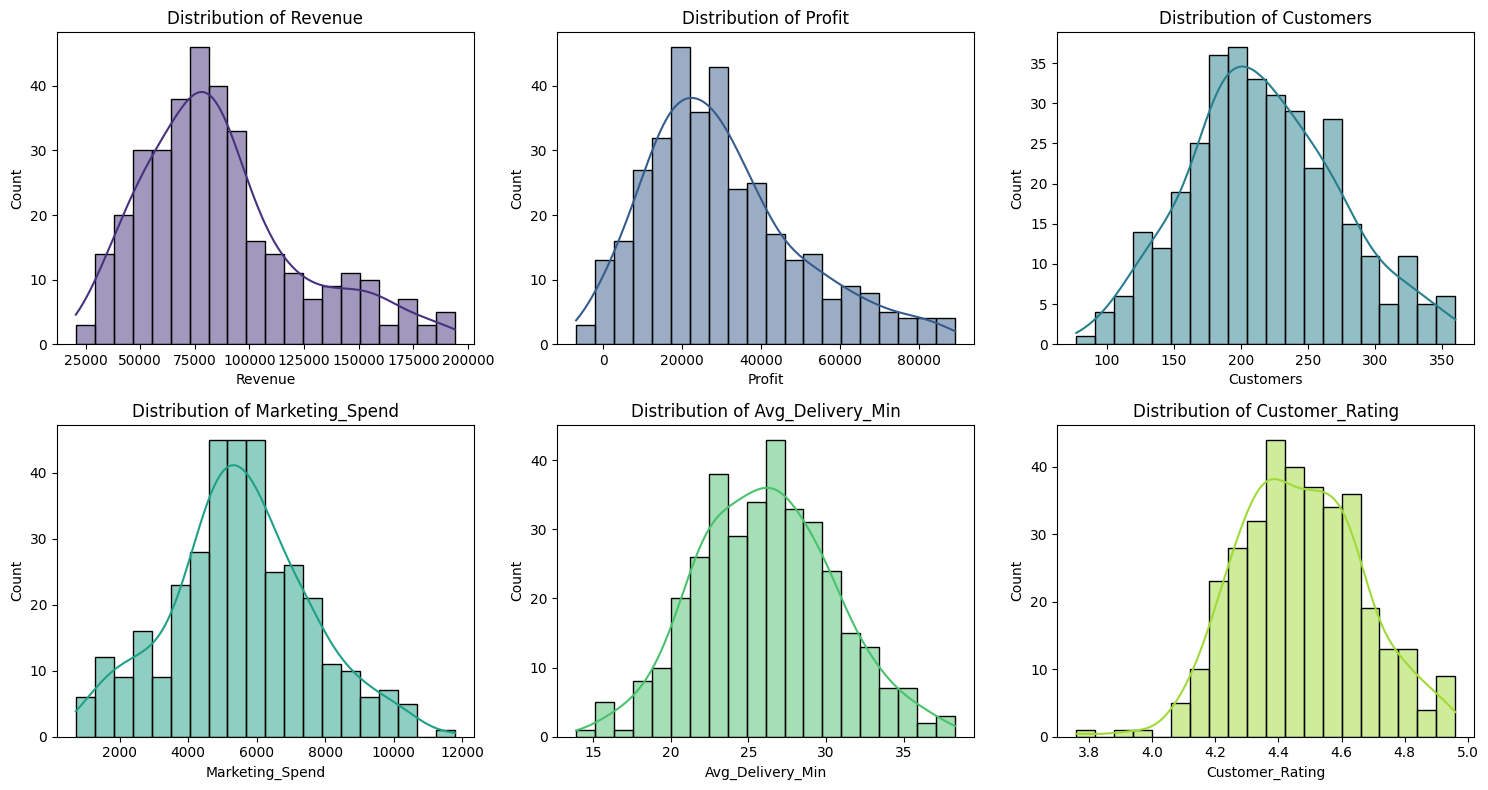

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
dist_cols = ["Revenue", "Profit", "Customers", "Marketing_Spend", "Avg_Delivery_Min", "Customer_Rating"]
colors = sns.color_palette("viridis", len(dist_cols))

for ax, col, color in zip(axes.flat, dist_cols, colors):
    sns.histplot(df[col], bins=20, kde=True, color=color, ax=ax)
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)

plt.tight_layout()
plt.show()

`Revenue`, `Profit`, and `Marketing_Spend` all show a right-skewed shape and
`Customer_Rating` is left-skewed

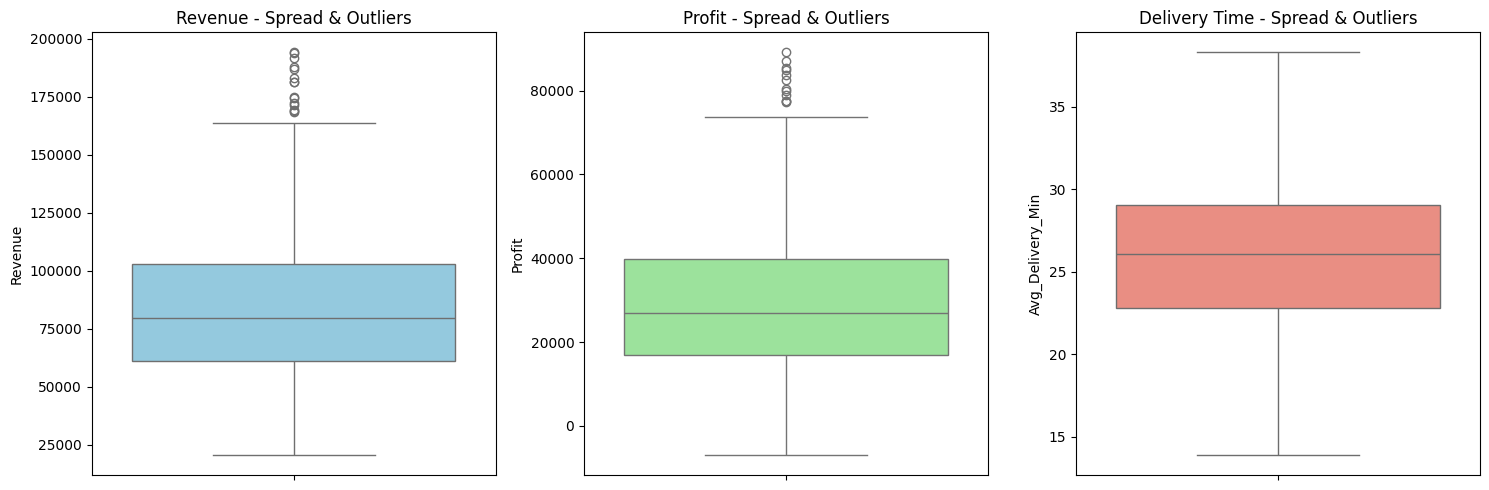

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.boxplot(y=df["Revenue"], ax=axes[0], color="skyblue")
axes[0].set_title("Revenue - Spread & Outliers")

sns.boxplot(y=df["Profit"], ax=axes[1], color="lightgreen")
axes[1].set_title("Profit - Spread & Outliers")

sns.boxplot(y=df["Avg_Delivery_Min"], ax=axes[2], color="salmon")
axes[2].set_title("Delivery Time - Spread & Outliers")

plt.tight_layout()
plt.show()

Box plots confirm the skew seen in the histograms -
`Revenue` and `Profit` have several high-end outliers

In [17]:
branch_summary = df.groupby("Branch", observed=True).agg(
    Avg_Customers=("Customers", "mean"),
    Avg_Revenue=("Revenue", "mean"),
    Avg_Profit=("Profit", "mean"),
    Avg_Profit_Margin=("Profit_Margin_Percent", "mean"),
    Avg_Rating=("Customer_Rating", "mean"),
    Avg_Delivery_Min=("Avg_Delivery_Min", "mean")
).round(2).sort_values("Avg_Revenue", ascending=False)

branch_summary

,Avg_Customers,Avg_Revenue,Avg_Profit,Avg_Profit_Margin,Avg_Rating,Avg_Delivery_Min
Branch,,,,,,
Bengaluru,227.50,90732.12,31890.91,31.11,4.47,26.56
Hyderabad,220.79,88804.90,31402.98,31.99,4.47,25.52
Pune,214.92,88107.49,31265.57,32.20,4.54,25.53
Delhi,213.97,87573.87,31385.30,31.80,4.49,25.69
Srinagar,214.73,86746.47,30302.92,31.69,4.48,25.97
Jaipur,223.27,86746.16,30469.70,32.50,4.47,26.58
Kochi,209.06,85574.62,28902.04,30.23,4.42,25.84
Mumbai,213.77,80779.25,26580.99,29.91,4.44,26.86


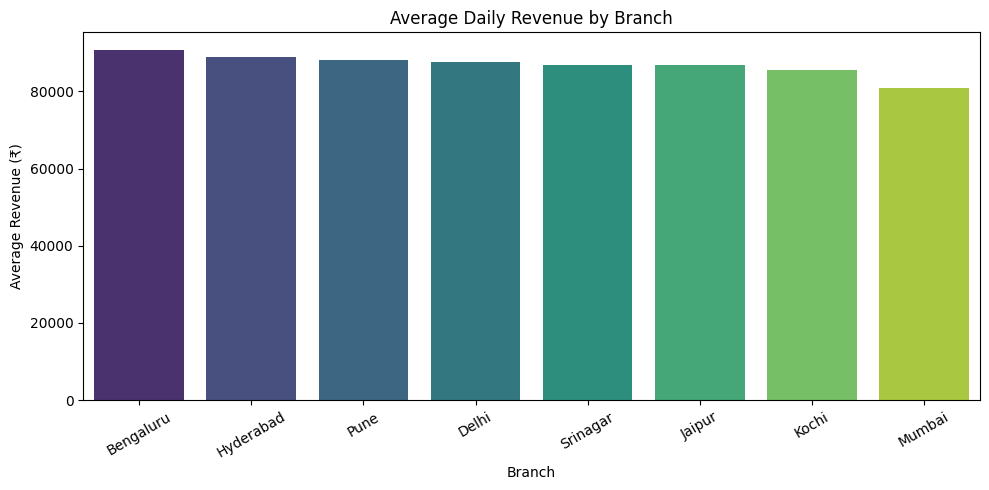

In [18]:
fig, ax = plt.subplots(figsize=(10, 5))
order = branch_summary.index
sns.barplot(x=branch_summary.index, y=branch_summary["Avg_Revenue"], order=order,
            hue=branch_summary.index, palette="viridis", legend=False, ax=ax)
ax.set_title("Average Daily Revenue by Branch")
ax.set_xlabel("Branch")
ax.set_ylabel("Average Revenue (₹)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [19]:
region_summary = df.groupby("Region", observed=True).agg(
    Avg_Customers=("Customers", "mean"),
    Avg_Revenue=("Revenue", "mean"),
    Avg_Profit=("Profit", "mean"),
    Avg_Profit_Margin=("Profit_Margin_Percent", "mean"),
    Avg_Rating=("Customer_Rating", "mean")
).round(2).sort_values("Avg_Revenue", ascending=False)

region_summary

,Avg_Customers,Avg_Revenue,Avg_Profit,Avg_Profit_Margin,Avg_Rating
Region,,,,,
South,218.93,88320.22,30690.57,31.08,4.45
North,217.65,86946.94,30625.96,32.01,4.48
West,214.30,84126.72,28720.86,30.96,4.49


In [20]:
store_type_summary = df.groupby("Store_Type", observed=True).agg(
    Avg_Customers=("Customers", "mean"),
    Avg_Revenue=("Revenue", "mean"),
    Avg_Profit=("Profit", "mean"),
    Avg_Profit_Margin=("Profit_Margin_Percent", "mean"),
    Avg_Staff=("Staff_Count", "mean"),
    Avg_Delivery_Min=("Avg_Delivery_Min", "mean"),
    Avg_Rating=("Customer_Rating", "mean")
).round(2).sort_values("Avg_Revenue", ascending=False)

store_type_summary

,Avg_Customers,Avg_Revenue,Avg_Profit,Avg_Profit_Margin,Avg_Staff,Avg_Delivery_Min,Avg_Rating
Store_Type,,,,,,,
Premium,298.73,152867.31,62890.24,40.80,17.60,26.40,4.46
Standard,224.98,87268.67,30630.79,34.15,12.54,25.98,4.47
Express,161.29,52327.16,12742.14,21.34,7.96,26.17,4.46


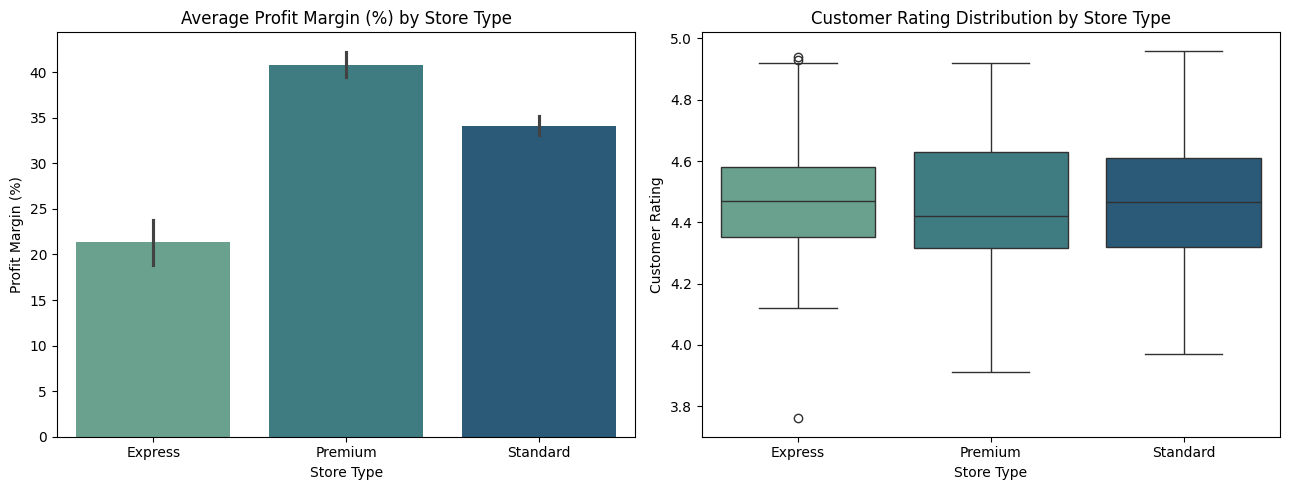

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.barplot(data=df, x="Store_Type", y="Profit_Margin_Percent", hue="Store_Type",
            estimator=np.mean, palette="crest", legend=False, ax=axes[0])
axes[0].set_title("Average Profit Margin (%) by Store Type")
axes[0].set_xlabel("Store Type")
axes[0].set_ylabel("Profit Margin (%)")

sns.boxplot(data=df, x="Store_Type", y="Customer_Rating", hue="Store_Type",
            palette="crest", legend=False, ax=axes[1])
axes[1].set_title("Customer Rating Distribution by Store Type")
axes[1].set_xlabel("Store Type")
axes[1].set_ylabel("Customer Rating")

plt.tight_layout()
plt.show()

`Premium` stores
post a noticeably higher average profit margin than `Express` outlets, consistent with a
premium format commanding higher prices relative to its cost base

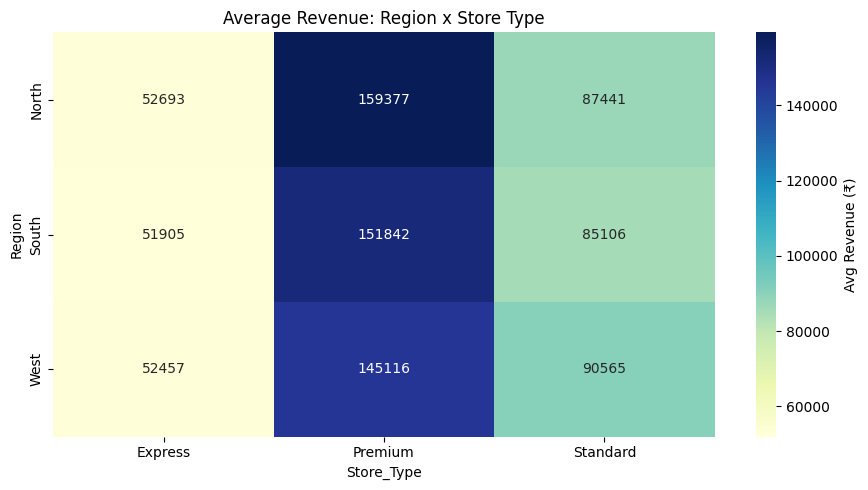

In [22]:
fig, ax = plt.subplots(figsize=(9, 5))
pivot = df.pivot_table(index="Region", columns="Store_Type", values="Revenue",
                        aggfunc="mean", observed=True)
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="YlGnBu", ax=ax, cbar_kws={"label": "Avg Revenue (₹)"})
ax.set_title("Average Revenue: Region x Store Type")
plt.tight_layout()
plt.show()

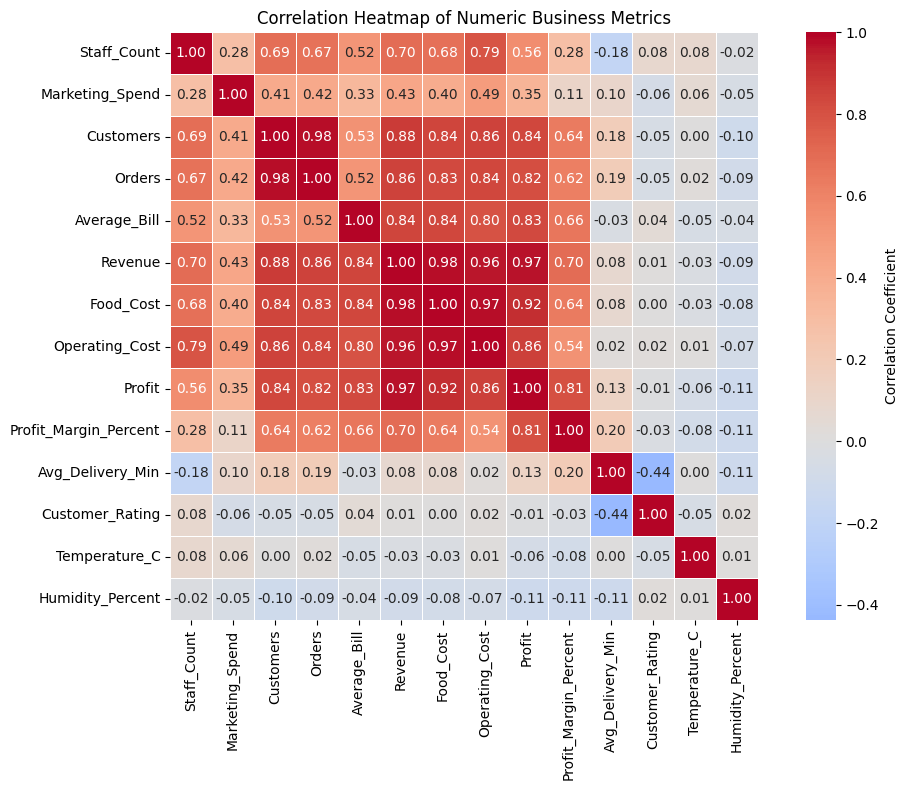

In [23]:
corr_matrix = df[numeric_cols].corr()
fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, cbar_kws={"label": "Correlation Coefficient"}, ax=ax)
ax.set_title("Correlation Heatmap of Numeric Business Metrics")
plt.tight_layout()
plt.show()

In [24]:
corr_pairs = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)).stack()
strongest = corr_pairs.abs().sort_values(ascending=False).head(10)

print("Top 10 strongest correlations (by absolute value):")
for (var1, var2), _ in strongest.items():
    print(f"  {var1:<20} <-> {var2:<20}  r = {corr_matrix.loc[var1, var2]:.2f}")

Top 10 strongest correlations (by absolute value):
  Customers            <-> Orders                r = 0.98
  Revenue              <-> Food_Cost             r = 0.98
  Food_Cost            <-> Operating_Cost        r = 0.97
  Revenue              <-> Profit                r = 0.97
  Revenue              <-> Operating_Cost        r = 0.96
  Food_Cost            <-> Profit                r = 0.92
  Customers            <-> Revenue               r = 0.88
  Operating_Cost       <-> Profit                r = 0.86
  Orders               <-> Revenue               r = 0.86
  Customers            <-> Operating_Cost        r = 0.86


 `Customers`, `Orders`, and `Revenue` are very strongly correlated —
more customers directly translates into more orders and revenue

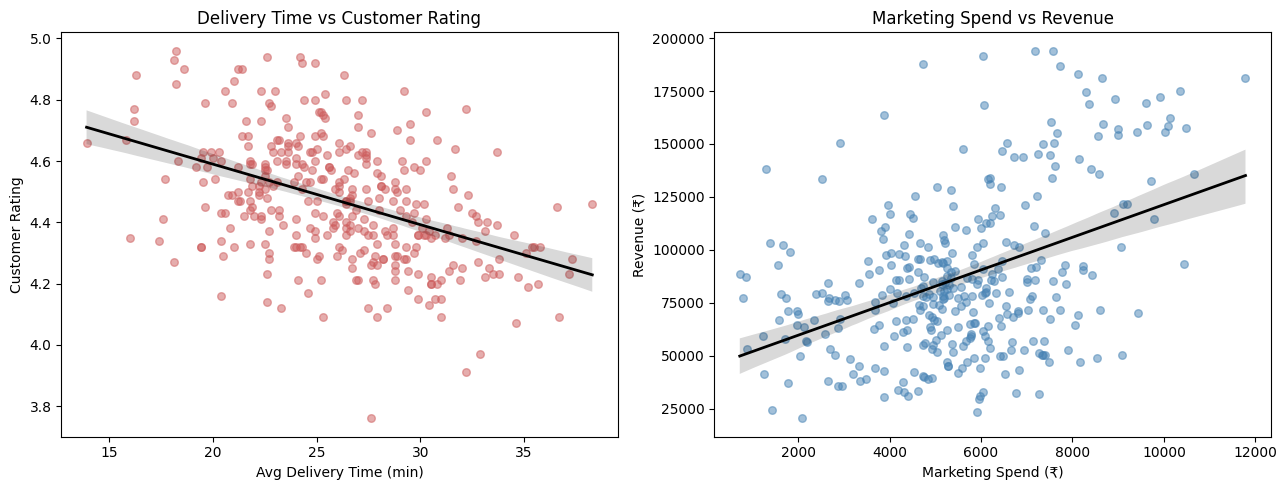

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.regplot(data=df, x="Avg_Delivery_Min", y="Customer_Rating", ax=axes[0],
            scatter_kws={"alpha": 0.5, "s": 30, "color": "indianred"},
            line_kws={"color": "black", "linewidth": 2})
axes[0].set_title("Delivery Time vs Customer Rating")
axes[0].set_xlabel("Avg Delivery Time (min)")
axes[0].set_ylabel("Customer Rating")

sns.regplot(data=df, x="Marketing_Spend", y="Revenue", ax=axes[1],
            scatter_kws={"alpha": 0.5, "s": 30, "color": "steelblue"},
            line_kws={"color": "black", "linewidth": 2})
axes[1].set_title("Marketing Spend vs Revenue")
axes[1].set_xlabel("Marketing Spend (₹)")
axes[1].set_ylabel("Revenue (₹)")

plt.tight_layout()
plt.show()

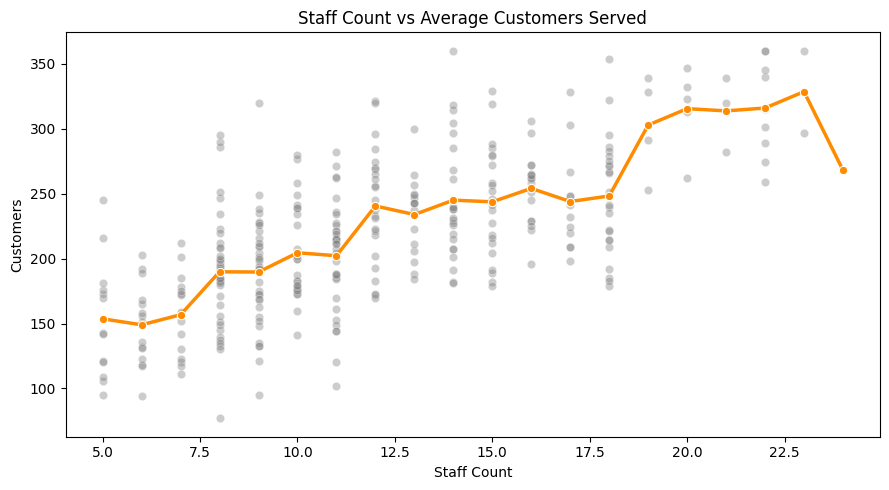

In [26]:
fig, ax = plt.subplots(figsize=(9, 5))
staff_corr = df.groupby("Staff_Count")["Customers"].mean().reset_index()
sns.scatterplot(data=df, x="Staff_Count", y="Customers", alpha=0.4, color="gray", ax=ax)
sns.lineplot(data=staff_corr, x="Staff_Count", y="Customers", color="darkorange", linewidth=2.5, marker="o", ax=ax)
ax.set_title("Staff Count vs Average Customers Served")
ax.set_xlabel("Staff Count")
ax.set_ylabel("Customers")
plt.tight_layout()
plt.show()

There's a visible positive relationship between staff count and customers served,
which makes sense operationally